In [72]:
import numpy as np
import pandas as pd
import sklearn as sk

1. Загрузите файл classification.csv. В нем записаны истинные классы
объектов выборки (колонка true) и ответы некоторого классификатора (колонка predicted).


In [73]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_intro/09/classification.csv')
true = data['true']
pred = data['pred']

2. Заполните таблицу ошибок классификации:
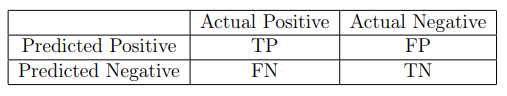

Для этого подсчитайте величины TP, FP, FN и TN согласно их
определениям. Например, FP — это количество объектов, имеющих
класс 0, но отнесенных алгоритмом к классу 1. Ответ в данном
вопросе — четыре числа через пробел.


TP - истина 1, предсказано 1

TN - истина 0, предсказано 0

FN - истина 1, предсказано 0

FP - истина 0, предсказано 1

In [74]:
TP, TN, FN, FP = 0, 0, 0, 0
for _, row in data.iterrows():
  t = row['true']
  p = row['pred']

  if t == 1 and p == 1:
    TP += 1
  elif t == 0 and p == 0:
    TN += 1
  elif t == 1 and p == 0:
    FN += 1
  elif t == 0 and p == 1:
    FP += 1

print(TP, FP, FN, TN)

43 34 59 64


3. Посчитайте основные метрики качества классификатора:
+ Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
+ Precision (точность) — sklearn.metrics.accuracy.precision_score
+ Recall (полнота) — sklearn.metrics.recall_score
+ F-мера — sklearn.metrics.f1_score


In [75]:
accuracy = sk.metrics.accuracy_score(true, pred)
precision = sk.metrics.precision_score(true, pred)
recall = sk.metrics.recall_score(true, pred)
f_score = sk.metrics.f1_score(true, pred)
print(round(accuracy,2), round(precision,2), round(recall,2), round(f_score,2))

0.54 0.56 0.42 0.48


4. Имеется четыре обученных классификатора. В файле scores.csv записаны истинные классы и значения степени принадлежности положительному классу для каждого классификатора на некоторой
выборке:
+ для логистической регрессии — вероятность положительного
класса (колонка score_logreg),
+ для SVM — отступ от разделяющей поверхности (колонка score_svm),
+ для метрического алгоритма — взвешенная сумма классов соседей (колонка score_knn),
+ для решающего дерева — доля положительных объектов в листе (колонка score_tree).

Загрузите этот файл.


In [76]:
scores = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_intro/09/scores.csv')

5. Посчитайте площадь под ROC-кривой для каждого классификатора. Какой классификатор имеет наибольшее значение метрики
AUC-ROC (укажите название столбца с ответами этого классификатора)? Воспользуйтесь функцией sklearn.metrics.roc_auc_score.


In [77]:
y = scores['true']
logreg_roc = sk.metrics.roc_auc_score(y, scores['score_logreg'])
svm_roc = sk.metrics.roc_auc_score(y, scores['score_svm'])
knn_roc = sk.metrics.roc_auc_score(y, scores['score_knn'])
tree_roc = sk.metrics.roc_auc_score(y, scores['score_tree'])
roc = {'score_logreg':logreg_roc, 'score_svm':svm_roc, 'score_knn':knn_roc, 'score_tree':tree_roc}
max_roc = max(roc, key=roc.get)
print(max_roc)

score_logreg


6. Какой классификатор достигает наибольшей точности (Precision)
при полноте (Recall) не менее 70% (укажите название столбца с ответами этого классификатора)? Какое значение точности при этом
получается?


In [78]:
logreg_prc = sk.metrics.precision_recall_curve(y, scores['score_logreg'])
svm_prc = sk.metrics.precision_recall_curve(y, scores['score_svm'])
knn_prc = sk.metrics.precision_recall_curve(y, scores['score_knn'])
tree_prc = sk.metrics.precision_recall_curve(y, scores['score_tree'])

logreg_prc_df = pd.DataFrame({
    'precision': logreg_prc[0],
    'recall': logreg_prc[1]
})
svm_prc_df = pd.DataFrame({
    'precision': svm_prc[0],
    'recall': svm_prc[1]
})
knn_prc_df = pd.DataFrame({
    'precision': knn_prc[0],
    'recall': knn_prc[1]
})
tree_prc_df = pd.DataFrame({
    'precision': tree_prc[0],
    'recall': tree_prc[1]
})

In [79]:
max_logreg_precision = logreg_prc_df[logreg_prc_df['recall']>=0.7]['precision'].max()
max_svm_precision = svm_prc_df[svm_prc_df['recall']>=0.7]['precision'].max()
max_knn_precision = knn_prc_df[knn_prc_df['recall']>=0.7]['precision'].max()
max_tree_precision = tree_prc_df[tree_prc_df['recall']>=0.7]['precision'].max()
precisions = {'score_logreg':max_logreg_precision, 'score_svm':max_svm_precision, 'score_knn':max_knn_precision, 'score_tree':max_tree_precision}
max_precision = max(roc, key=roc.get)
print(max_precision, round(precisions.get(max_precision), 2))

score_logreg 0.63
